In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO NO DISCOUNT CUSTOMERS
print("\n🎯 FILTERING TO NO DISCOUNT CUSTOMERS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with no discount (discount = 0 or no discount)
has_no_discount = df_quotes.groupby('numero_compte')['mt_remise_exceptionnelle_ht'].apply(
    lambda x: (x >= 0).all()  # No negative discounts
)

no_discount_ids = has_no_discount[has_no_discount].index.tolist()

# Filter data
df_quotes_no_discount = df_quotes[df_quotes['numero_compte'].isin(no_discount_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"No discount customers: {len(no_discount_ids):,}")
print(f"Quotes: {len(df_quotes_no_discount):,}")

# Save to file
df_quotes_no_discount.to_csv('cleaned_quote_data_no_discount.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_no_discount.csv")


🎯 FILTERING TO NO DISCOUNT CUSTOMERS
Original customers: 25,716
No discount customers: 17,597
Quotes: 24,028

✅ Saved to cleaned_quote_data_no_discount.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_no_discount.csv')


📊 Original quote data: 24,028 quotes from 17,597 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 17,597, Quotes: 23,489
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 17,597 customers | 35.3% converters
⏱️  Execution time: 7.7 seconds
⚠️  7.7s (target was 3s)
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 24,028
  Total customers: 17,597
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 17,597
    Quotes after filter: 23,508
⚡ Processing 17,597 customers with sequence features...
  Processed 5,000/17,597 customers
  Processed 10,000/17,597 customers
  Processed 15,000/17,597 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 17,597

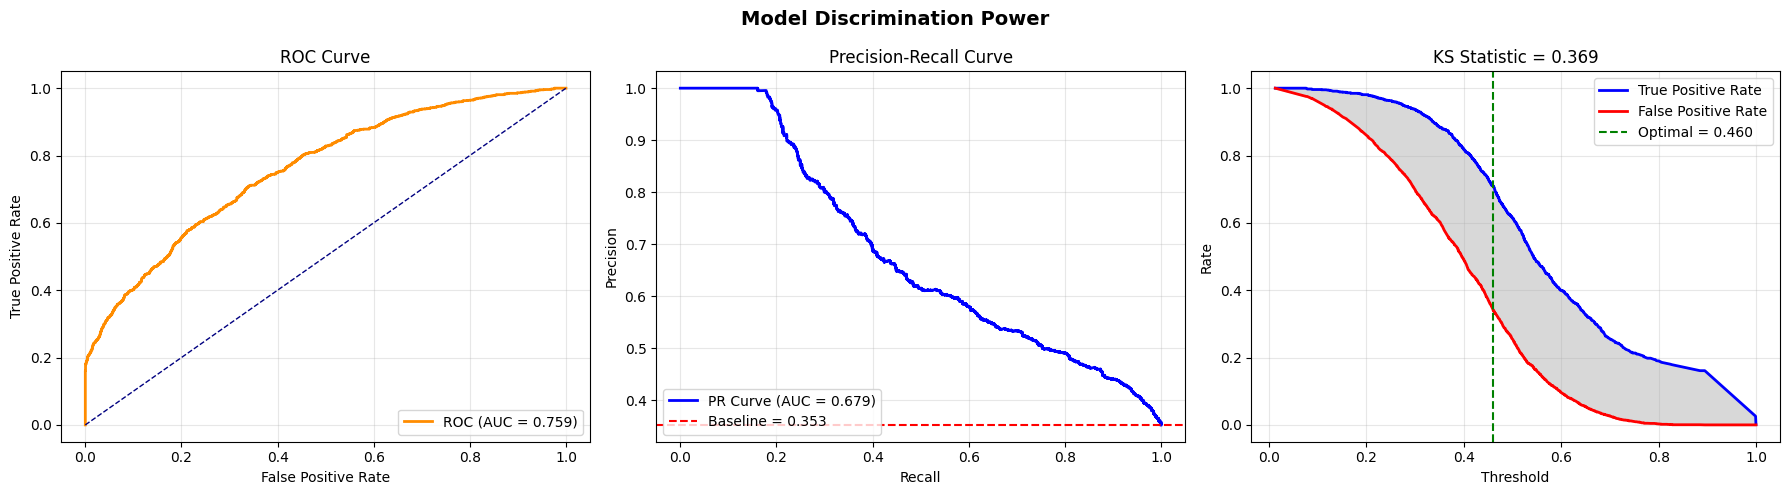

• ROC-AUC: 0.7593
• PR-AUC: 0.6789
• KS Statistic: 0.369 (MODERATE discrimination)
• Optimal Threshold: 0.460

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.898
Decile 10 mean prob: 0.132


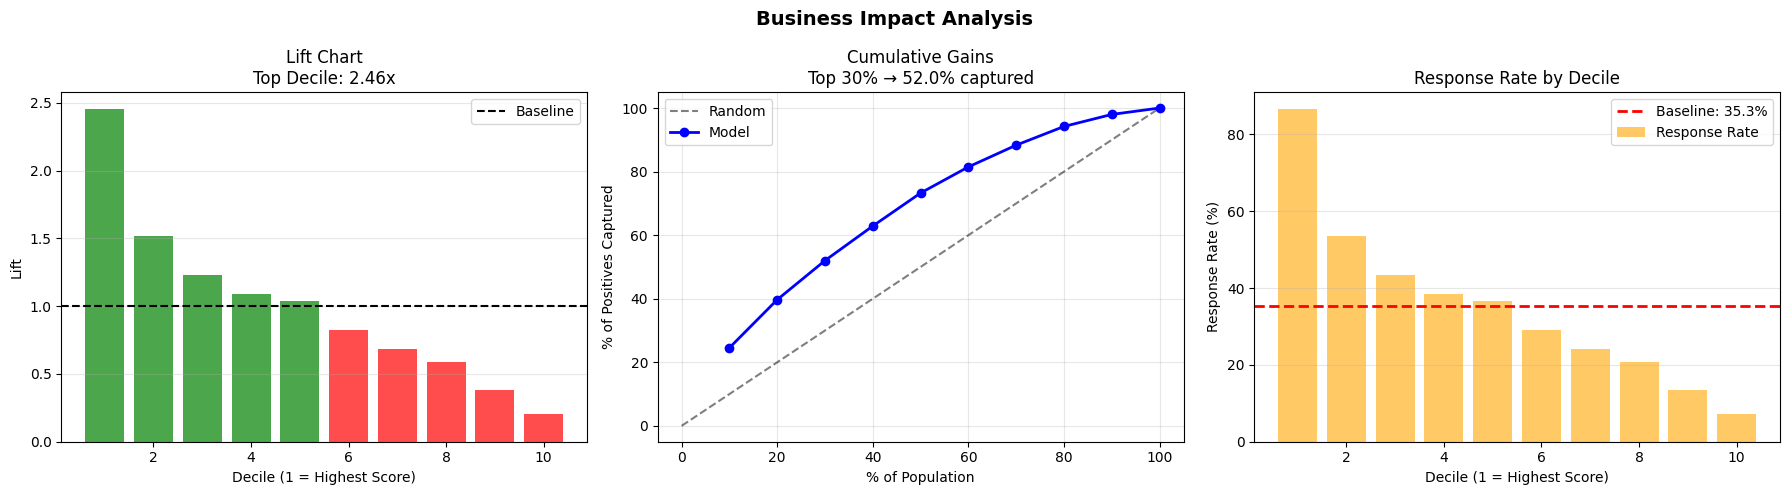

• Top Decile Lift: 0.20x
• Top 30% captures: 52.0% of positives
• Baseline response rate: 35.3%
• Top decile response: 86.6%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


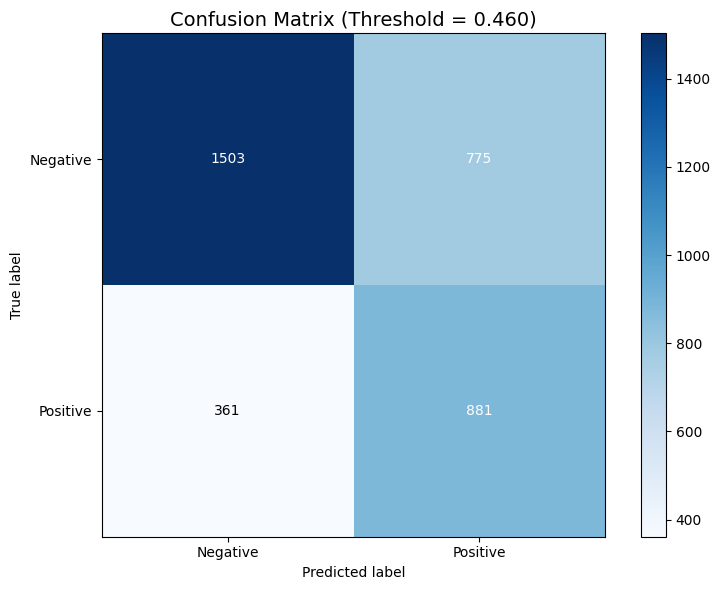

At threshold 0.460:
• Accuracy: 0.677
• Precision: 0.532
• Recall: 0.709
• F1-Score: 0.608
• True Positives: 881
• False Positives: 775
• True Negatives: 1503
• False Negatives: 361

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.369 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.20x better than random
   Coverage: Top 30% → 52.0% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7593 (Excellent if >0.8)
   PR-AUC: 0.6789 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.460
   Precision at threshold: 0.532
   Recall at threshold: 0.709

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                        feature  importance
178     quote_consistency_score    0.099761
180   decision_efficiency_score    0.051663
167            is_quick_decider    0.040927
150                   max_price    0.020016
38          model_variety_score    0.018486
242         price_x_consistency    0.017495
214      speed_complexity_ratio    0.0165

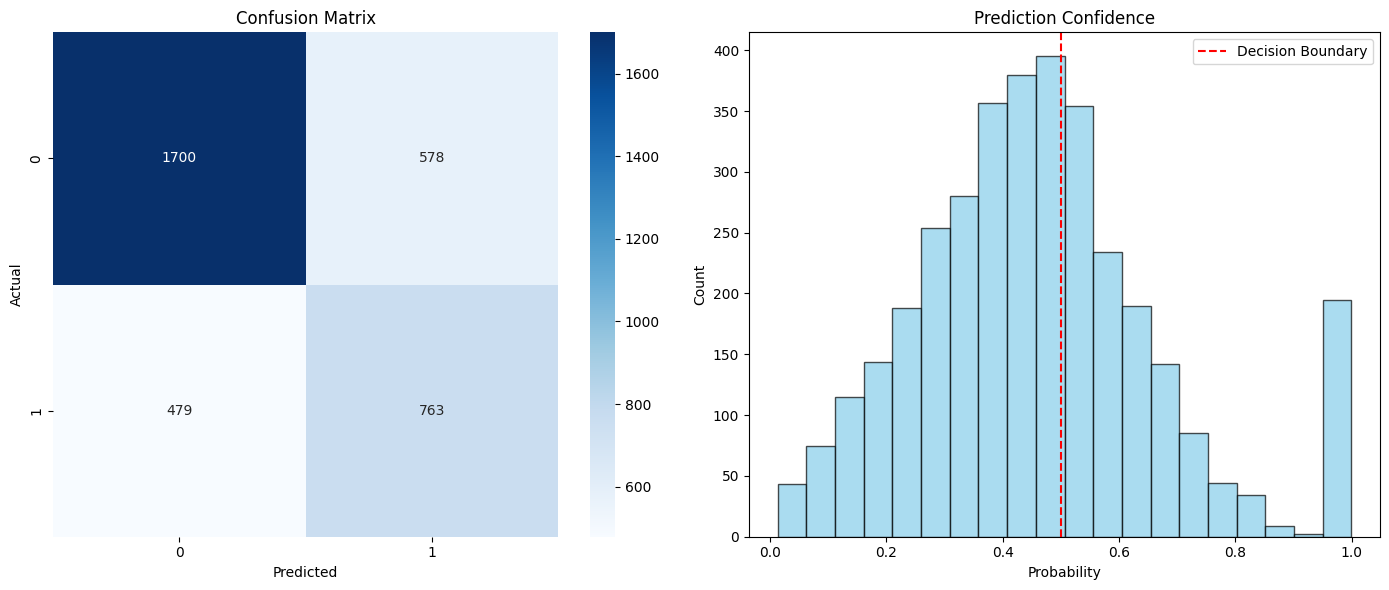

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])